# Stage 2 — Modeling diagnostics (baseline vs SMOTE)

**Audience:** Readers who want to see how XGBoost behaves on the nine fixed PJTL metrics and how class imbalance is handled.

**Outcome:** A trained baseline model, threshold sweep, optional SMOTE comparison, ablations, and saved metrics under `results/stage2/`.

**Data:** `results/stage1/stage1_model_frame.csv` (built from `inputs/readiness_training_base.csv` after the table build + sync). Refresh pipeline from repo root:

1. `python code/scripts/build_phase1_canonical_base.py`
2. `python code/scripts/build_readiness_training_base.py`
3. `python code/inference_engine/scripts/sync_inputs_from_phase1.py`

Gate rules for `label_ready` match **`code/config/pjtl_kpis_and_formulas.json`** (same as the backend).

## Research questions
1. At which probability threshold on `P(Ready)` do we get the best trade-off between catching true Ready weeks vs avoiding false Ready?
2. How much does SMOTE change operating metrics vs the real-data baseline?
3. Which single-feature drops move false Ready or missed Ready the most (ablation)?


## How to read the metrics (operational mapping)

**Label:** `label_ready=1` means all nine gate metrics pass per `code/config/pjtl_kpis_and_formulas.json`; `0` means at least one fails. The model estimates the probability of that all-pass outcome.

**Threshold** on `P(Ready)` converts probabilities into discrete actions. Lower threshold -> more Ready predictions -> higher sensitivity (catch more true Ready) but more false Ready (Type I under our convention below).

**F1** is the harmonic mean of precision and recall. It is a useful single number for balanced error costs, but it is not a business utility function unless leadership explicitly says precision and recall are equally costly.

**Sensitivity (recall, TPR)** = TP / (TP+FN). Of all truly Ready cases, how many did we call Ready? Missed Ready trips hurt revenue/continuity assumptions.

**Specificity (TNR)** = TN / (TN+FP). Of all truly Not Ready cases, how many did we correctly hold back? False Ready trips hurt safety/capacity promises.

**PPV / NPV** translate into operator trust: precision of a Ready call, and correctness of a Not Ready call.

**Convention for Type I / II** (positive class = label_ready=1 = Ready):
- **Type I (false positive)**: false Ready (predict Ready when not).
- **Type II (false negative)**: missed Ready (predict Not Ready when Ready).

These costs are not equal by default; the threshold sweep exposes the trade-off on this snapshot.


In [1]:
from __future__ import annotations
import json
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    f1_score, confusion_matrix, accuracy_score,
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="talk")

HERE = Path.cwd().resolve()
def _repo_root(here: Path) -> Path:
    for p in [here, *here.parents]:
        if (p / "code" / "config" / "pjtl_kpis_and_formulas.json").is_file():
            return p
    raise RuntimeError("Cannot find repo root (missing code/config/pjtl_kpis_and_formulas.json)")

REPO_ROOT = _repo_root(HERE)
ENGINE = REPO_ROOT / "code" / "inference_engine"
CODE_ROOT = REPO_ROOT / "code"
INPUTS = REPO_ROOT / "code" / "intermediates" / "inference_inputs"
S1 = REPO_ROOT / "code" / "outputs" / "reports" / "stage1"
R2 = REPO_ROOT / "code" / "outputs" / "reports" / "stage2"
P2 = REPO_ROOT / "code" / "outputs" / "plots" / "stage2"
R2.mkdir(parents=True, exist_ok=True)
P2.mkdir(parents=True, exist_ok=True)

KPI_DOC = CODE_ROOT / "config" / "pjtl_kpis_and_formulas.json"
_kpi_cfg = json.loads(KPI_DOC.read_text(encoding="utf-8"))
BF = [m["key"] for m in _kpi_cfg["readiness_metrics"]]

df = pd.read_csv(S1 / "stage1_model_frame.csv")
X = df[BF].astype(float)
y = df["label_ready"].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pos = float(y_train.sum())
neg = float(len(y_train) - y_train.sum())
spw = neg / max(pos, 1.0)

def build_model(scale_pos_weight: float) -> XGBClassifier:
    return XGBClassifier(
        n_estimators=400, max_depth=5, learning_rate=0.04, subsample=0.9, colsample_bytree=0.85,
        reg_alpha=0.1, reg_lambda=1.2, min_child_weight=2, objective="binary:logistic", eval_metric="logloss",
        random_state=42, scale_pos_weight=scale_pos_weight,
    )

display(Markdown(f"Train/test: {len(X_train)}/{len(X_test)} | scale_pos_weight={spw:.3f}"))


Train/test: 3200/800 | scale_pos_weight=0.973

### Nine launch-readiness KPIs

Same definitions as Stage 1 / backend: `code/config/pjtl_kpis_and_formulas.json`.


In [2]:
_rule_txt = {"gte": "value ≥ threshold", "lte": "value ≤ threshold", "lt": "value < threshold (strict)"}
kpi_rows = []
for m in _kpi_cfg["readiness_metrics"]:
    kpi_rows.append({
        "#": m["metric_number"],
        "KPI": m["display_name"],
        "Target": m["target_phrase"],
        "Pass rule": _rule_txt.get(m["pass_rule"], m["pass_rule"]),
        "Column": m["key"],
    })
display(pd.DataFrame(kpi_rows))


,#,KPI,Target,Pass rule,Column
0,1,Vehicle utilization,at least 95%,value ≥ threshold,vehicle_utilization
1,2,Billed utilization,at least 105%,value ≥ threshold,billed_utilization
2,3,Total volume pool,at least 120%,value ≥ threshold,total_volume_pool
3,4,Revenue per Kent-Leg,at least $70 per Kent-Leg,value ≥ threshold,revenue_per_kent_leg
4,5,High-acuity trip mix (SA/SC),at least 5%,value ≥ threshold,high_acuity_share
5,6,Non-billable no-show rate,strictly below 10%,value < threshold (strict),non_billable_noshow
6,7,Road hours per vehicle per day,at least 9 hours,value ≥ threshold,road_hours_per_vehicle
7,8,Contract concentration,no single contract above 20% of volume or revenue,value ≤ threshold,contract_concentration
8,9,Cost per road hour,at most $50 per road hour,value ≤ threshold,cost_per_road_hour


In [3]:

baseline = build_model(spw)
baseline.fit(X_train, y_train, verbose=False)
p_base = baseline.predict_proba(X_test)[:, 1]

thr_grid = np.arange(0.2, 0.81, 0.01)
rows = []

def metrics_at_threshold(y_true, p, t, variant):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    return {
        "variant": variant,
        "threshold": float(t),
        "accuracy": float(accuracy_score(y_true, pred)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, p)),
        "sensitivity": float(sens),
        "specificity": float(spec),
        "ppv": float(tp / max(tp + fp, 1)),
        "npv": float(tn / max(tn + fn, 1)),
        "balanced_accuracy": float((sens + spec) / 2),
        "false_ready_rate": float(fp / max(fp + tn, 1)),
        "missed_ready_rate": float(fn / max(fn + tp, 1)),
    }

for t in thr_grid:
    rows.append(metrics_at_threshold(y_test, p_base, t, "baseline"))
thr_df = pd.DataFrame(rows)
opt = thr_df.sort_values("f1", ascending=False).iloc[0]
best_thr = float(opt["threshold"])
thr_df.to_csv(R2 / "threshold_metrics_baseline.csv", index=False)
display(opt.to_frame().T)


,variant,threshold,accuracy,f1,roc_auc,sensitivity,specificity,ppv,npv,balanced_accuracy,false_ready_rate,missed_ready_rate
0,baseline,0.2,0.9975,0.997537,0.99995,1.0,0.994937,0.995086,1.0,0.997468,0.005063,0.0


### Demo: XGBoost `predict_proba` on held-out rows

Two examples from the test split: probability of Ready (`label_ready=1`) and the predicted class at the Stage 2 best-F1 threshold.


In [4]:
# Uses `baseline`, `best_thr`, `X_test`, `y_test` from the previous cell
_demo_pos = int(y_test.reset_index(drop=True).eq(1).idxmax()) if y_test.eq(1).any() else 0
_demo_neg = int(y_test.reset_index(drop=True).eq(0).idxmax()) if y_test.eq(0).any() else min(1, len(y_test) - 1)
for label, idx in [("likely Ready (first positive in test)", _demo_pos), ("likely Not Ready (first negative in test)", _demo_neg)]:
    idx = max(0, min(idx, len(X_test) - 1))
    row = X_test.iloc[[idx]]
    p_ready = float(baseline.predict_proba(row)[0, 1])
    cls = int(p_ready >= best_thr)
    print(f"{label}: P(Ready)={p_ready:.4f} | threshold={best_thr:.4f} -> predicted class {cls} (true {int(y_test.iloc[idx])})")


likely Ready (first positive in test): P(Ready)=0.9914 | threshold=0.2000 -> predicted class 1 (true 1)
likely Not Ready (first negative in test): P(Ready)=0.0111 | threshold=0.2000 -> predicted class 0 (true 0)


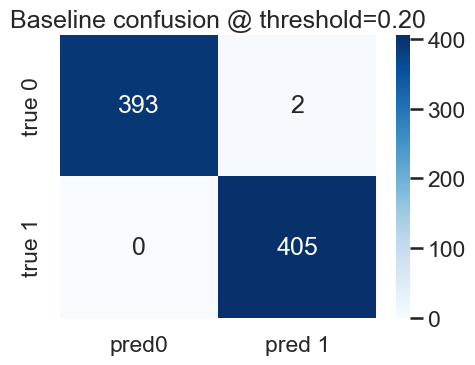

In [5]:

# Confusion matrix at best-F1 threshold (baseline)
pred = (p_base >= best_thr).astype(int)
cm = confusion_matrix(y_test, pred, labels=[0, 1])
pd.DataFrame(cm, index=["true_not_ready","true_ready"], columns=["pred_not_ready","pred_ready"]).to_csv(R2 / "confusion_baseline_best_f1.csv")
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["pred0","pred 1"], yticklabels=["true 0","true 1"])
plt.title(f"Baseline confusion @ threshold={best_thr:.2f}")
plt.tight_layout()
plt.savefig(P2 / "confusion_baseline.png", dpi=150)
plt.show()


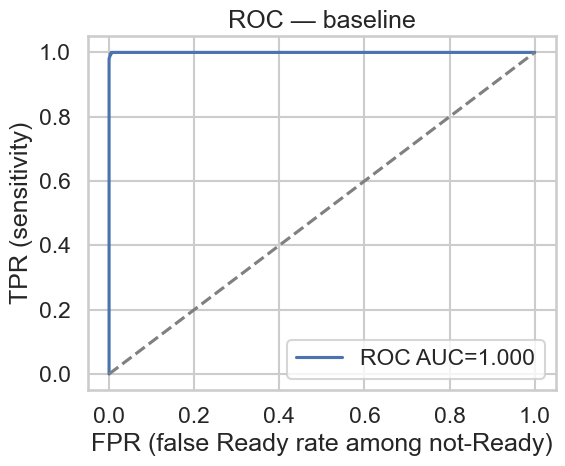

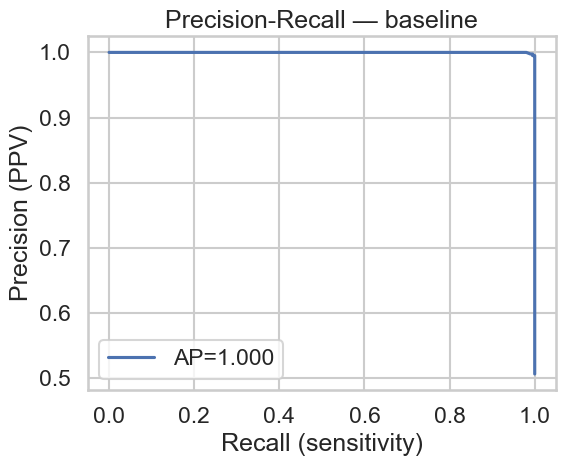

In [6]:

# ROC and PR curves (baseline)
fpr, tpr, _ = roc_curve(y_test, p_base)
prec, rec, _ = precision_recall_curve(y_test, p_base)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC AUC={roc_auc_score(y_test,p_base):.3f}")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("FPR (false Ready rate among not-Ready)")
plt.ylabel("TPR (sensitivity)")
plt.title("ROC — baseline")
plt.legend()
plt.tight_layout()
plt.savefig(P2 / "roc_baseline.png", dpi=150)
plt.show()

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP={average_precision_score(y_test,p_base):.3f}")
plt.xlabel("Recall (sensitivity)")
plt.ylabel("Precision (PPV)")
plt.title("Precision-Recall — baseline")
plt.legend()
plt.tight_layout()
plt.savefig(P2 / "pr_baseline.png", dpi=150)
plt.show()


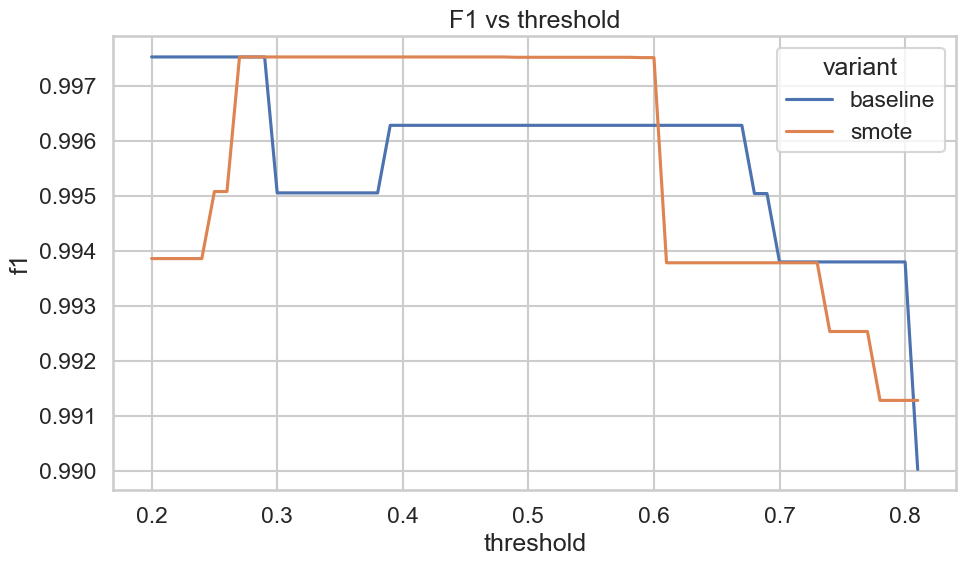

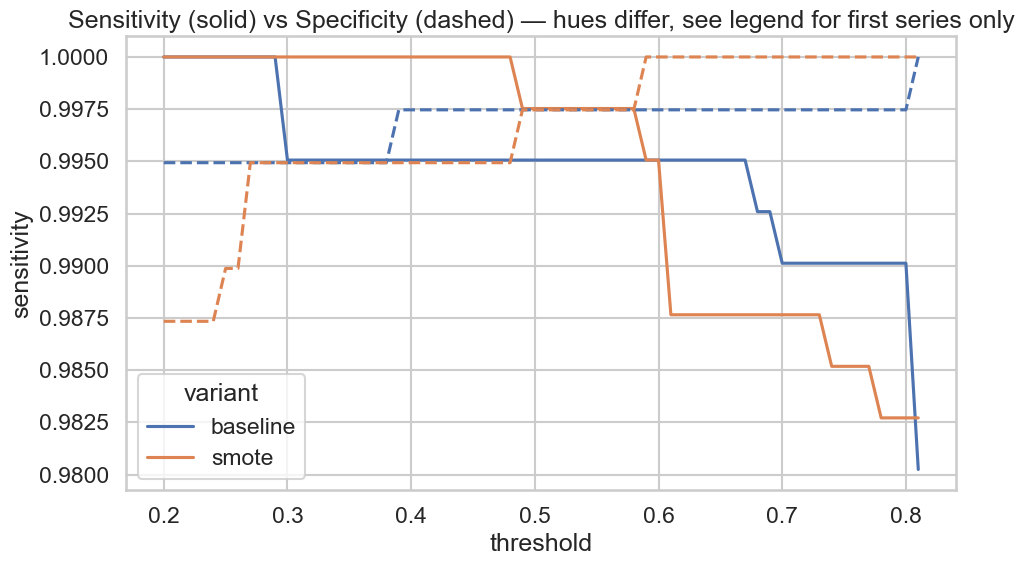

In [7]:

smote_available = False
smote_rows = []
try:
    from imblearn.over_sampling import SMOTE
    sm = SMOTE(random_state=42)
    Xr, yr = sm.fit_resample(X_train, y_train)
    sm_model = build_model(1.0)
    sm_model.fit(Xr, yr, verbose=False)
    p_sm = sm_model.predict_proba(X_test)[:, 1]
    for t in thr_grid:
        smote_rows.append(metrics_at_threshold(y_test, p_sm, t, "smote"))
    smote_available = True
except Exception as e:
    display(Markdown(f"**SMOTE experiment unavailable:** {e}"))

all_thr = thr_df.copy()
if smote_available:
    smote_df = pd.DataFrame(smote_rows)
    smote_df.to_csv(R2 / "threshold_metrics_smote.csv", index=False)
    all_thr = pd.concat([all_thr, smote_df], ignore_index=True)
all_thr.to_csv(R2 / "threshold_metrics_by_variant.csv", index=False)

plt.figure(figsize=(10,6))
sns.lineplot(all_thr, x="threshold", y="f1", hue="variant")
plt.title("F1 vs threshold")
plt.tight_layout()
plt.savefig(P2 / "threshold_f1_by_variant.png", dpi=150)
plt.show()

plt.figure(figsize=(10,6))
sns.lineplot(all_thr, x="threshold", y="sensitivity", hue="variant")
sns.lineplot(all_thr, x="threshold", y="specificity", hue="variant", linestyle="--", legend=False)
plt.title("Sensitivity (solid) vs Specificity (dashed) — hues differ, see legend for first series only")
plt.tight_layout()
plt.savefig(P2 / "sens_spec_by_variant.png", dpi=150)
plt.show()



### SMOTE narrative (inference)
**Observation:** SMOTE changes the training distribution by creating synthetic minority examples.

**Inference:** It can lift recall-like metrics on small positives but may **overfit** noise or distort calibration on real operations.

**Decision relevance:** Treat SMOTE as a **sensitivity analysis**, not a substitute for collecting more real Ready/Not Ready weeks unless governance signs off.


,dropped_feature,delta_fp,delta_fn,delta_tp,delta_tn,f1,roc_auc
1,billed_utilization,31,0,0,-31,0.960854,0.995837
5,non_billable_noshow,27,0,0,-27,0.965435,0.992874
3,revenue_per_kent_leg,24,0,0,-24,0.968900,0.996112
4,high_acuity_share,23,0,0,-23,0.970060,0.994915
2,total_volume_pool,22,0,0,-22,0.971223,0.998006
8,cost_per_road_hour,20,0,0,-20,0.973558,0.994130
6,road_hours_per_vehicle,19,0,0,-19,0.974729,0.994555
0,vehicle_utilization,18,0,0,-18,0.975904,0.994930
7,contract_concentration,18,0,0,-18,0.975904,0.993530


/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_95062/3661937182.py:32: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/kz/s8yn3fr907s7j_b541v31y9r0000gn/T/ipykernel_95062/3661937182.py:33: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  plt.savefig(P2 / "ablation_f1.png", dpi=150)
/Users/santoshdesai/Downloads/PJTLxRideYourWay/code/inference_engine/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8658 (\N{RIGHTWARDS DOUBLE ARROW}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


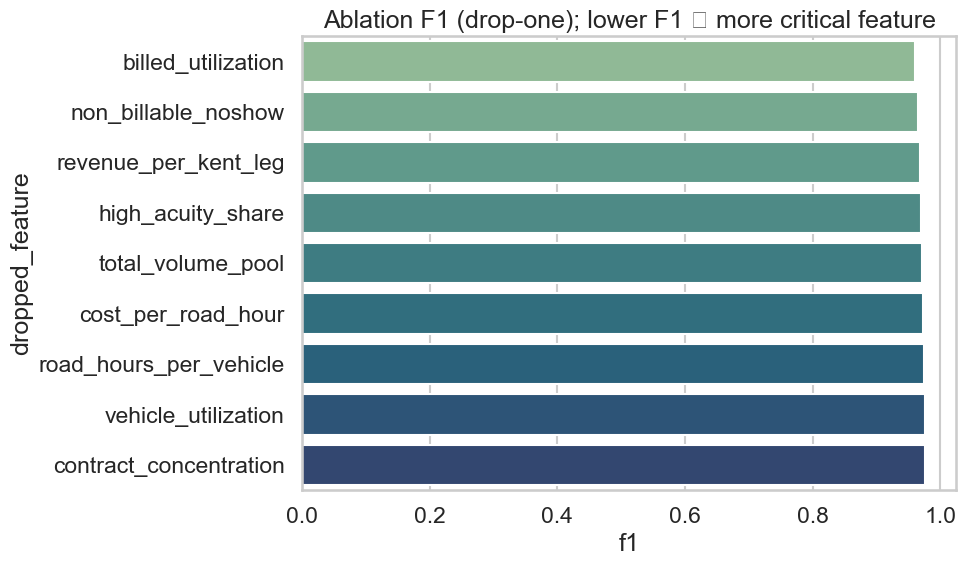

In [8]:

# Ablation: drop one feature, measure confusion deltas vs full model at fixed threshold

def confusion_counts(y_true, p, t):
    pred = (p >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

base_counts = confusion_counts(y_test, p_base, best_thr)
abl = []
for feat in BF:
    keep = [c for c in BF if c != feat]
    m = build_model(spw)
    m.fit(X_train[keep], y_train, verbose=False)
    p = m.predict_proba(X_test[keep])[:, 1]
    c = confusion_counts(y_test, p, best_thr)
    abl.append({
        "dropped_feature": feat,
        "delta_fp": c["fp"] - base_counts["fp"],
        "delta_fn": c["fn"] - base_counts["fn"],
        "delta_tp": c["tp"] - base_counts["tp"],
        "delta_tn": c["tn"] - base_counts["tn"],
        "f1": float(f1_score(y_test, (p >= best_thr).astype(int), zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, p)),
    })
abl_df = pd.DataFrame(abl).sort_values(["delta_fp", "delta_fn"], ascending=[False, False])
abl_df.to_csv(R2 / "ablation_confusion_deltas.csv", index=False)
display(abl_df)

plt.figure(figsize=(10,6))
sns.barplot(abl_df, x="f1", y="dropped_feature", hue="dropped_feature", palette="crest", legend=False)
plt.title("Ablation F1 (drop-one); lower F1 ⇒ more critical feature")
plt.tight_layout()
plt.savefig(P2 / "ablation_f1.png", dpi=150)
plt.show()


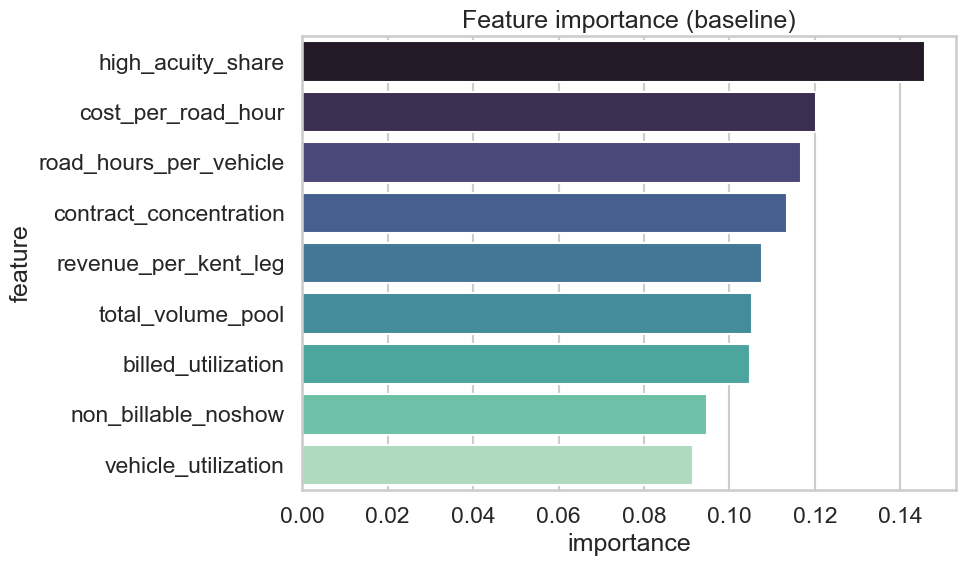

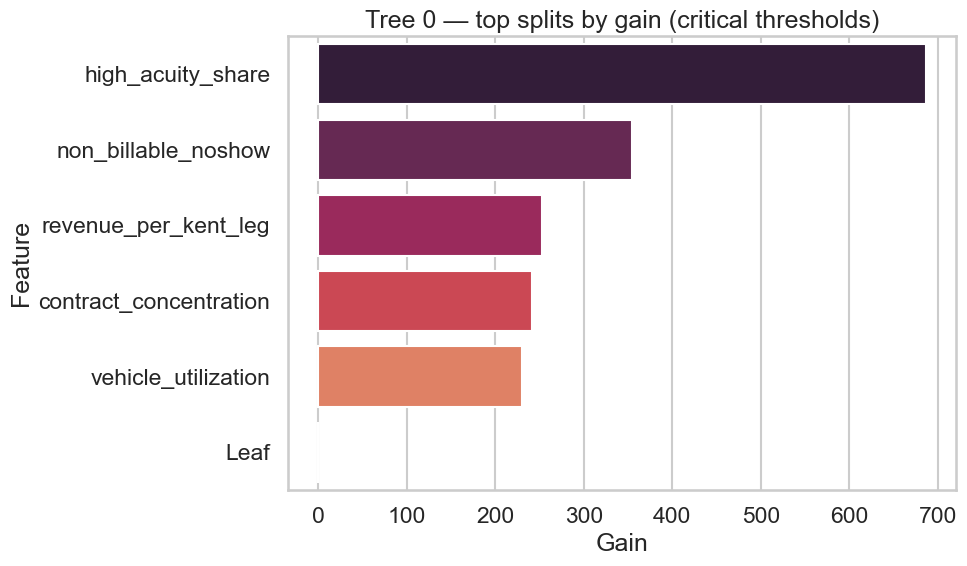

In [9]:

# Feature importance + tree structure without Graphviz
imp = pd.DataFrame({"feature": BF, "importance": baseline.feature_importances_}).sort_values("importance", ascending=False)
imp.to_csv(R2 / "feature_importance.csv", index=False)
plt.figure(figsize=(10,6))
sns.barplot(imp.head(12), x="importance", y="feature", hue="feature", palette="mako", legend=False)
plt.title("Feature importance (baseline)")
plt.tight_layout()
plt.savefig(P2 / "feature_importance.png", dpi=150)
plt.show()

tdf = baseline.get_booster().trees_to_dataframe()
tdf.to_csv(R2 / "tree_table_all.csv", index=False)
# Tree 0 top splits by gain
t0 = tdf[tdf["Tree"] == 0].sort_values("Gain", ascending=False).head(15)
t0.to_csv(R2 / "tree0_top_splits.csv", index=False)
plt.figure(figsize=(10,6))
sns.barplot(t0, x="Gain", y="Feature", hue="Feature", palette="rocket", legend=False)
plt.title("Tree 0 — top splits by gain (critical thresholds)")
plt.tight_layout()
plt.savefig(P2 / "tree0_top_splits.png", dpi=150)
plt.show()


In [10]:

summary = {
    "best_baseline_threshold": best_thr,
    "best_baseline_f1": float(opt["f1"]),
    "best_baseline_sensitivity": float(opt["sensitivity"]),
    "best_baseline_specificity": float(opt["specificity"]),
    "best_baseline_false_ready_rate": float(opt["false_ready_rate"]),
    "best_baseline_missed_ready_rate": float(opt["missed_ready_rate"]),
    "smote_available": smote_available,
    "feature_order": BF,
}
(R2 / "stage2_summary.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
display(Markdown("Wrote `stage2_summary.json` for Stage 3 export threshold."))


Wrote `stage2_summary.json` for Stage 3 export threshold.

In [11]:
# Answers to Stage 2 research questions + concrete feature names (from saved CSVs)
import json
import pandas as pd
from IPython.display import display, Markdown

st2 = json.loads((R2 / "stage2_summary.json").read_text(encoding="utf-8"))
abl = pd.read_csv(R2 / "ablation_confusion_deltas.csv")
fp = abl[abl["delta_fp"] > 0].sort_values("delta_fp", ascending=False)
fn = abl[abl["delta_fn"] > 0].sort_values("delta_fn", ascending=False)
imp = pd.read_csv(R2 / "feature_importance.csv")
tree = pd.read_csv(R2 / "tree0_top_splits.csv").head(6)

fp_names = ", ".join(fp["dropped_feature"].tolist()) if len(fp) else "(none positive in this run)"
fn_names = ", ".join(fn["dropped_feature"].tolist()) if len(fn) else "(none positive in this run)"
fp_top = fp.head(3)["dropped_feature"].tolist()
fn_top = fn.head(3)["dropped_feature"].tolist()
smote_txt = "SMOTE ran: compare `threshold_metrics_smote.csv` to baseline." if st2.get("smote_available") else "SMOTE did not run (see error message above if any)."

md = f"""## Answers to the research questions (Stage 2)

**Q1 — Which threshold trades off false Ready vs missed Ready?** On this snapshot, Stage 2 picked **{st2['best_baseline_threshold']:.3f}** on `P(Ready)` to maximize **F1** (best F1 **{st2['best_baseline_f1']:.3f}**), with sensitivity **{st2['best_baseline_sensitivity']:.3f}** and specificity **{st2['best_baseline_specificity']:.3f}**. See `threshold_metrics_baseline.csv` for the full curve.

**Q2 — SMOTE vs real rows only?** {smote_txt} If curves diverge, treat SMOTE as a **what-if**, not a replacement for real operational data.

**Q3 — Which features tie to false Ready vs missed Ready (ablation)?**  
- **Inflate false Ready** when removed (`delta_fp` > 0): **{fp_names}**. Largest in this run: **{', '.join(fp_top) if fp_top else 'n/a'}**.  
- **Inflate missed Ready** when removed (`delta_fn` > 0): **{fn_names}**. Largest in this run: **{', '.join(fn_top) if fn_top else 'n/a'}**.  
(Full table: `ablation_confusion_deltas.csv`.)

**Q4 — What does the first tree emphasize?** Early splits (by gain) use features: **{', '.join(tree['Feature'].astype(str).tolist())}** at split values in `tree0_top_splits.csv` — these are **model-internal** cut points, not PJTL gate thresholds.

### Model reliance (gain-based, same nine features)
Top importances: **{', '.join(imp.head(3)['feature'].tolist())}** — see `feature_importance.csv`.
"""
display(Markdown(md))


## Answers to the research questions (Stage 2)

**Q1 — Which threshold trades off false Ready vs missed Ready?** On this snapshot, Stage 2 picked **0.200** on `P(Ready)` to maximize **F1** (best F1 **0.998**), with sensitivity **1.000** and specificity **0.995**. See `threshold_metrics_baseline.csv` for the full curve.

**Q2 — SMOTE vs real rows only?** SMOTE ran: compare `threshold_metrics_smote.csv` to baseline. If curves diverge, treat SMOTE as a **what-if**, not a replacement for real operational data.

**Q3 — Which features tie to false Ready vs missed Ready (ablation)?**  
- **Inflate false Ready** when removed (`delta_fp` > 0): **billed_utilization, non_billable_noshow, revenue_per_kent_leg, high_acuity_share, total_volume_pool, cost_per_road_hour, road_hours_per_vehicle, vehicle_utilization, contract_concentration**. Largest in this run: **billed_utilization, non_billable_noshow, revenue_per_kent_leg**.  
- **Inflate missed Ready** when removed (`delta_fn` > 0): **(none positive in this run)**. Largest in this run: **n/a**.  
(Full table: `ablation_confusion_deltas.csv`.)

**Q4 — What does the first tree emphasize?** Early splits (by gain) use features: **high_acuity_share, non_billable_noshow, revenue_per_kent_leg, contract_concentration, vehicle_utilization, Leaf** at split values in `tree0_top_splits.csv` — these are **model-internal** cut points, not PJTL gate thresholds.

### Model reliance (gain-based, same nine features)
Top importances: **high_acuity_share, cost_per_road_hour, road_hours_per_vehicle** — see `feature_importance.csv`.
